In [2]:
!python process_sheets.py --input raw_sheets --out dataset --debug


Saved dataset successfully!
label
0    200
1    200
2    200
3    200
4    200
5    200
dtype: int64


Test Accuracy: 0.525

Confusion Matrix:
[[30  2  0  2  2  4]
 [ 1 22  9  1  3  4]
 [ 1 10 18  7  2  2]
 [ 0  5  9 19  3  4]
 [ 1  4  2  2 23  8]
 [ 3  4  7  4  8 14]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8333    0.7500    0.7895        40
           1     0.4681    0.5500    0.5057        40
           2     0.4000    0.4500    0.4235        40
           3     0.5429    0.4750    0.5067        40
           4     0.5610    0.5750    0.5679        40
           5     0.3889    0.3500    0.3684        40

    accuracy                         0.5250       240
   macro avg     0.5324    0.5250    0.5270       240
weighted avg     0.5324    0.5250    0.5270       240



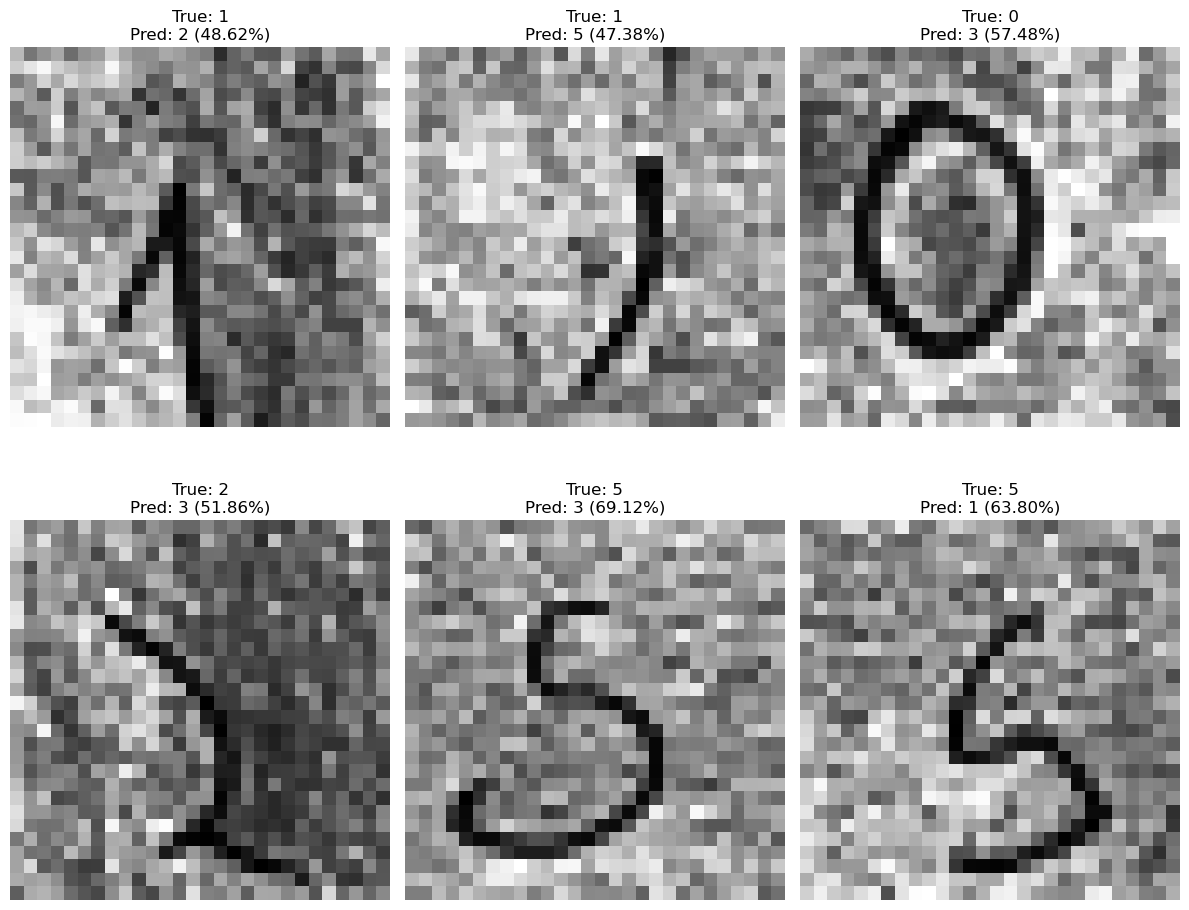

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#loading and preprocessing
df = pd.read_csv('dataset/labels.csv')
X, y = [], []

for index, row in df.iterrows():
    img = Image.open(row['filepath']).convert('L')
    img_array = np.array(img)
    # FLATTEN & NORMALIZE (Required for Methodology section)
    X.append(img_array.reshape(784) / 255.0)
    y.append(row['label'])

X = np.array(X)
y = np.array(y)

#splitting (80/20 split)
SEED = 123
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

#training Multinomial Logistic Regression (Softmax)
#using 'lbfgs' solver as standard for multinomial
model = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED)
model.fit(X_train, y_train)

#evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test) # Needed for probabilities requirement

print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

#visualizing 6 misclassified examples with probabilities
mistakes_idx = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    idx = mistakes_idx[i]
    image = X_test[idx].reshape(28, 28)
    
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    pred_proba = y_proba[idx][pred_label] # probability of the wrong guess
    
    ax.imshow(image, cmap='gray')
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({pred_proba:.2%})")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# 1. Get full probability distributions for all test samples
y_proba = model.predict_proba(X_test)

# 2. Find misclassified indices
mistakes_idx = np.where(y_pred != y_test)[0]

#print the table for the 6 mistakes
print("- TABLE DATA FOR 6 MISTAKES -")
print(f"{'Img #':<6} | {'True':<5} | {'Pred':<5} | {'P(0)':<6} | {'P(1)':<6} | {'P(2)':<6} | {'P(3)':<6} | {'P(4)':<6} | {'P(5)':<6}")
for i in range(6):
    idx = mistakes_idx[i]
    p = y_proba[idx]
    print(f"{i+1:<6} | {y_test[idx]:<5} | {y_pred[idx]:<5} | {p[0]:.2f} | {p[1]:.2f} | {p[2]:.2f} | {p[3]:.2f} | {p[4]:.2f} | {p[5]:.2f}")

#finding a perfect prediction Q4
correct_idx = np.where(y_pred == y_test)[0][0] # Pick the first correct one
p_correct = y_proba[correct_idx]
print("\n- Q4: DATA FOR CORRECT PREDICTION -")
print(f"True Label: {y_test[correct_idx]} | Pred Label: {y_pred[correct_idx]}")
print(f"Probabilities: {np.round(p_correct, 3)}")

#find one specific "ambiguous" mistake Q4
p_wrong = y_proba[mistakes_idx[0]]
print("\n- Q4: DATA FOR MISTAKEN PREDICTION -")
print(f"True Label: {y_test[mistakes_idx[0]]} | Pred Label: {y_pred[mistakes_idx[0]]}")
print(f"Probabilities: {np.round(p_wrong, 3)}")

- TABLE DATA FOR 6 MISTAKES -
Img #  | True  | Pred  | P(0)   | P(1)   | P(2)   | P(3)   | P(4)   | P(5)  
1      | 1     | 2     | 0.00 | 0.43 | 0.49 | 0.00 | 0.07 | 0.02
2      | 1     | 5     | 0.13 | 0.30 | 0.00 | 0.01 | 0.08 | 0.47
3      | 0     | 3     | 0.03 | 0.01 | 0.09 | 0.57 | 0.09 | 0.21
4      | 2     | 3     | 0.00 | 0.03 | 0.36 | 0.52 | 0.09 | 0.01
5      | 5     | 3     | 0.13 | 0.02 | 0.11 | 0.69 | 0.00 | 0.05
6      | 5     | 1     | 0.00 | 0.64 | 0.03 | 0.04 | 0.07 | 0.22

- Q4: DATA FOR CORRECT PREDICTION -
True Label: 3 | Pred Label: 3
Probabilities: [0.006 0.005 0.088 0.899 0.    0.002]

- Q4: DATA FOR MISTAKEN PREDICTION -
True Label: 1 | Pred Label: 2
Probabilities: [0.    0.426 0.486 0.004 0.067 0.017]
